# Sustainable Development Goals Readiness Index 2030

This Jupyter Notebook focuses on the construction and analysis of the **SDG Readiness Index 2030**, which aims to assess how prepared countries are to achieve selected United Nations Sustainable Development Goals by the year 2030.

The notebook combines the cleaned and processed sub-index datasets developed from:

* SDG 3 - Good Health and Well-Being
* SDG 6 - Clean Water and Sanitation
* SDG 11 - Sustainable Cities and Communities

The purpose of this notebook is to standardise and analyse the combined indicators using multivariate analysis techniques such as:

* Correlation Analysis
* Variance Inflation Factor (VIF)
* Principal Component Analysis (PCA)
* Clustering Analysis

These methods are used to identify relationships between indicators, reduce dimensionality and group countries based on similar SDG readiness patterns.

The final stage of this notebook will involve weighting and aggregating the indicators to produce the overall **SDG Readiness Index 2030** for comparative country analysis.


### 1.1 Merge Datasets

In [50]:
import pandas as pd

sdg3_combined_df = pd.read_csv("Raw_Data/SDG_3_Good_Health_and_Well-Being/sdg3_combined.csv")

sdg6_combined_df = pd.read_csv("Raw_Data/SDG_6_Clean_Water_and_Sanitation/sdg6_combined.csv")

sdg11_combined_df = pd.read_csv("Raw_Data/SDG_11_Sustainable_Cities_and_Communities/sdg11_combined.csv")


print("SDG 3 Combined Dataset")
display(sdg3_combined_df.head())

print("SDG 6 Combined Dataset")
display(sdg6_combined_df.head())

print("SDG 11 Combined Dataset")
display(sdg11_combined_df.head())

SDG 3 Combined Dataset


,GeoAreaName,InfantMortality_2030_Predicted,DiseaseMortality_2030_Predicted,SuicideMortality_2030_Predicted
0,Afghanistan,37.457082,28.517287,3.145842
1,Albania,5.546873,4.123085,0.537856
2,Algeria,15.713803,10.728556,1.129431
3,Andorra,1.295250,0.000000,0.000000
4,Angola,12.002988,22.855689,7.281947


SDG 6 Combined Dataset


,GeoAreaName,Stress_2030_Predicted,DrinkingWater_2030_Predicted,Handwashing_2030_Predicted
0,Afghanistan,54.760000,35.766557,56.782834
1,Albania,2.836051,79.785542,0.000000
2,Algeria,175.482805,69.398306,85.653658
3,American Samoa,0.000000,92.731402,0.000000
4,Andorra,11.443845,90.639996,0.000000


SDG 11 Combined Dataset


,GeoAreaName,SlumPopulation_2030_Predicted,DisasterAffected_2030_Predicted
0,Afghanistan,75.339061,1609.393514
1,Albania,-5.932409,902.918922
2,Algeria,5.469330,231.992181
3,Andorra,0.000000,-24.487979
4,Angola,81.406761,119.414922


In [51]:
# Merge all SDG datasets using only matching GeoAreaName values

sdg_combined_df = (sdg3_combined_df.merge(sdg6_combined_df, on="GeoAreaName", how="inner").merge(sdg11_combined_df, on="GeoAreaName", how="inner"))

# Display result
print("Final Combined Dataset Shape:", sdg_combined_df.shape)

display(sdg_combined_df)

Final Combined Dataset Shape: (200, 9)


,GeoAreaName,InfantMortality_2030_Predicted,DiseaseMortality_2030_Predicted,SuicideMortality_2030_Predicted,Stress_2030_Predicted,DrinkingWater_2030_Predicted,Handwashing_2030_Predicted,SlumPopulation_2030_Predicted,DisasterAffected_2030_Predicted
0,Afghanistan,37.457082,28.517287,3.145842,54.760000,35.766557,56.782834,75.339061,1609.393514
1,Albania,5.546873,4.123085,0.537856,2.836051,79.785542,0.000000,-5.932409,902.918922
2,Algeria,15.713803,10.728556,1.129431,175.482805,69.398306,85.653658,5.469330,231.992181
3,Andorra,1.295250,0.000000,0.000000,11.443845,90.639996,0.000000,0.000000,-24.487979
4,Angola,12.002988,22.855689,7.281947,1.870000,0.000000,37.643818,81.406761,119.414922
...,...,...,...,...,...,...,...,...,...
195,Viet Nam,10.267658,19.265208,7.793217,17.553621,61.855982,90.606391,35.549101,-0.126799
196,World,0.000000,15.644420,7.499344,17.541811,76.607072,84.120878,22.081276,0.000000
197,Yemen,24.906752,24.719147,3.306455,311.829231,0.000000,68.580315,37.762881,-2556.458024
198,Zambia,23.839560,23.789934,6.785777,10.861360,0.000000,18.842607,42.997446,4141.474159


#### 1.2 Meaning of Indicators

| Indicator                | Meaning                                                                                                             |
| --------------------------------- | ------------------------------------------------------------------------------------------------------------------- |
| InfantMortality_2030_Predicted  | Infant mortality rate (deaths per 1,000 live births)                                                                |
| DiseaseMortality_2030_Predicted | Mortality rate attributed to cardiovascular disease, cancer, diabetes, or chronic respiratory disease (probability) |
| SuicideMortality_2030_Predicted | Suicide mortality rate, by sex (deaths per 100,000 population)                                                      |
| Stress_2030_Predicted           | Level of water stress, freshwater withdrawal as a proportion of available freshwater resources (%)                  |
| DrinkingWater_2030_Predicted    | Proportion of population using safely managed drinking water services, by urban/rural (%)                           |
| Handwashing_2030_Predicted      | Proportion of population with basic handwashing facilities on premises, by urban/rural (%)                          |
| SlumPopulation_2030_Predicted   | Proportion of urban population living in slums (%)                                                                  |
| DisasterAffected_2030_Predicted | Number of directly affected persons attributed to disasters per 100,000 population                                  |


### 2.1 Multivariate Analysis

#### 2.2 Heatmap

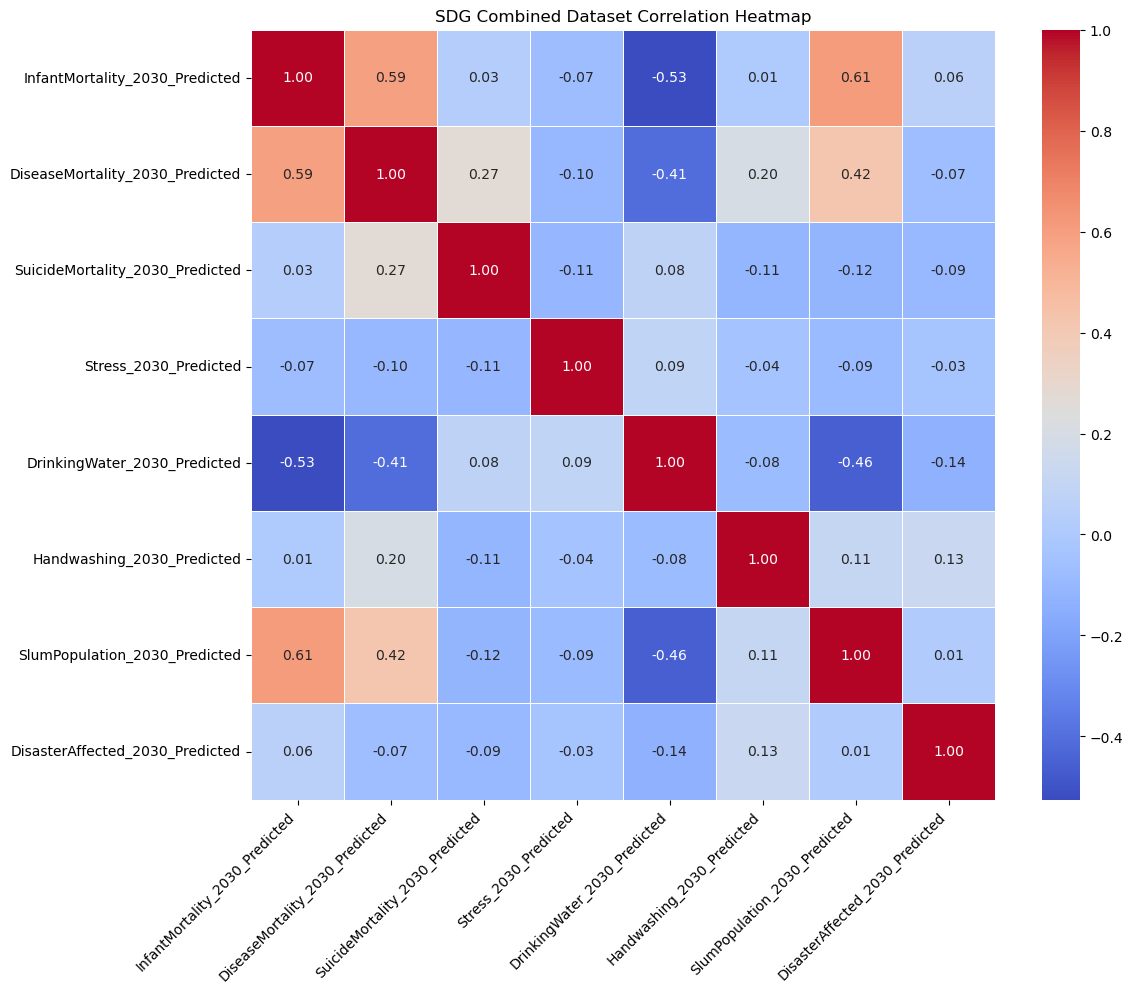

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

final_numeric = sdg_combined_df.select_dtypes(include='number')

correlation_matrix = final_numeric.corr()

# Plot heatmap
plt.figure(figsize=(12, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title("SDG Combined Dataset Correlation Heatmap")

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.show()

Correlation Analysis & Multicollinearity Assessment

**1. Strong Positive Correlations**

- **SlumPopulation_2030_Predicted vs. InfantMortality_2030_Predicted (0.61)**: This represents the strongest positive correlation in the dataset. This correlation is expected, as poorer living conditions and limited healthcare access within slum areas naturally drive higher infant mortality rates. However, at 0.61, the correlation is not high enough to suggest problematic multicollinearity. Both variables capture the distinct socioeconomic factors.

- **InfantMortality_2030_Predicted vs. DiseaseMortality_2030_Predicted (0.59)**: This strong relationship reflects how weaker overall healthcare infrastructure impacts multiple health metrics simultaneously. Despite the overlap, they both measure fundamentally different aspects of public health.

- **SlumPopulation_2030_Predicted vs. DiseaseMortality_2030_Predicted (0.42)**: A moderate and reasonable correlation, highlighting how poor urban living conditions negatively affect long-term community health outcomes.

**2. Strong Negative Correlations**

- **InfantMortality_2030_Predicted vs. DrinkingWater_2030_Predicted (-0.53)**: This is the strongest negative correlation, which logically shows that better access to safe drinking water directly relates to lower infant mortality rates.

- **SlumPopulation_2030_Predicted vs. DrinkingWater_2030_Predicted (-0.46)**: This expected negative correlation indicates that regions with larger slum populations generally face steeper challenges in providing reliable clean water infrastructure.

- **DiseaseMortality_2030_Predicted vs. DrinkingWater_2030_Predicted (-0.41)**: This underscores how improved clean water access serves as a foundational driver for lowering disease mortality and lifting overall public health.

#### 2.3 PCA 

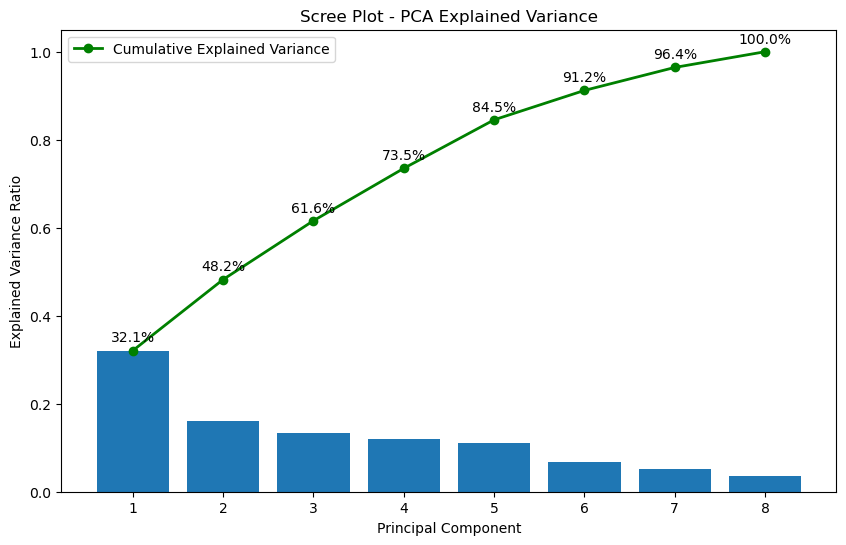

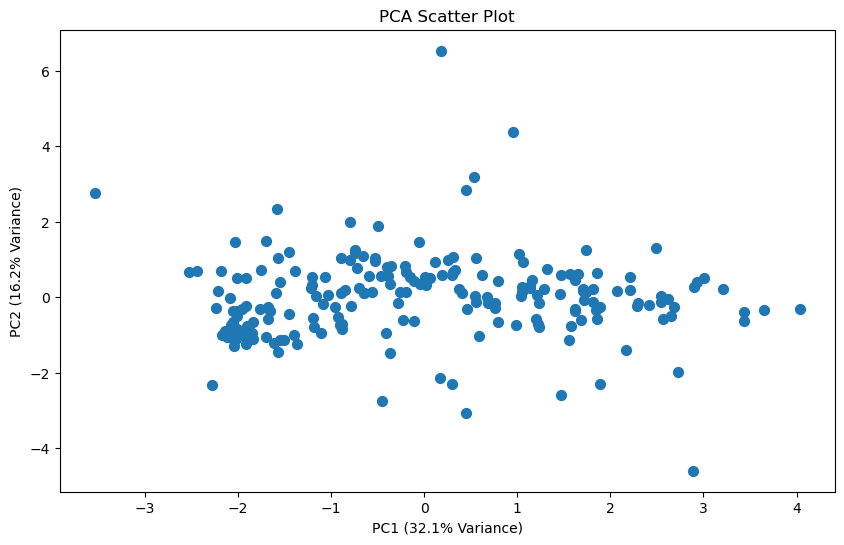

Kaiser Criterion Results


,Principal Component,Eigenvalue,Keep_Component
0,PC1,2.5779,True
1,PC2,1.2994,True
2,PC3,1.0746,True
3,PC4,0.9569,False
4,PC5,0.8869,False
5,PC6,0.5372,False
6,PC7,0.4201,False
7,PC8,0.2874,False



Number of PCs retained using Kaiser Criterion: 3


In [53]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np

final_numeric = sdg_combined_df.select_dtypes(include='number')

# Standardising the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(final_numeric)

pca = PCA()
pca_components = pca.fit_transform(scaled_data)

# Scree Plot (Bar Chart)
plt.figure(figsize=(10, 6))

# Bar chart for explained variance
plt.bar(
    range(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_
)

# Line plot for cumulative variance
plt.plot(
    range(1, len(np.cumsum(pca.explained_variance_ratio_)) + 1),
    np.cumsum(pca.explained_variance_ratio_),
    marker='o',
    linewidth=2,
    color='green',
    label='Cumulative Explained Variance'
)

# Adding percentage labels above each cumulative variance point
for i, value in enumerate(np.cumsum(pca.explained_variance_ratio_), start=1):
    plt.text(
        i,
        value + 0.02,
        f"{value * 100:.1f}%",
        ha='center'
    )

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot - PCA Explained Variance")

plt.xticks(range(1, len(pca.explained_variance_ratio_) + 1))
plt.grid(False) # data to ink ratio yet again ;O
plt.legend()

plt.show()

# PCA Scatter Plot (PC1 vs PC2)
plt.figure(figsize=(10, 6))

plt.scatter(
    pca_components[:, 0],
    pca_components[:, 1],
    s=50
)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% Variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% Variance)")
plt.title("PCA Scatter Plot")
plt.grid(False) # data to ink ratio ;)
plt.show()

# Kaiser Criterion 
kaiser_df = pd.DataFrame({
    'Principal Component': [f'PC{i+1}' for i in range(len(pca.explained_variance_))],
    'Eigenvalue': pca.explained_variance_,
    'Keep_Component': pca.explained_variance_ > 1
})
# Only retain PCs with eigenvalues greater than 1

print("Kaiser Criterion Results")
display(kaiser_df.round(4))

print(f"\nNumber of PCs retained using Kaiser Criterion: {(pca.explained_variance_ > 1).sum()}")

In my opinion, the PCA results show a fairly balanced spread of variance across multiple components rather than having a single dominant factor controlling the dataset. The scree plot indicates that PC1 explains approximately **32.1%** of the total variance, while PC2 explains around **16.2%**. Together, the first two principal components account for roughly **48.2%** of the dataset's variance.

I believe this is a positive outcome because it suggests that the SDG indicators are not overly dependent on one another and that the dataset captures multiple dimensions of performance across countries. If one component had explained the majority of the variance alone, it could indicate excessive overlap or redundancy between the variables I selected.

The cumulative variance reaching approximately **73.5% by PC4** and **84.5% by PC5** suggests that a relatively small number of principal components are capable of preserving most of the information contained within the original dataset. In my opinion, this demonstrates that the dataset structure is reasonably efficient while still maintaining diversity between indicators.

The Kaiser Criterion results further support this interpretation, with only the first **3 principal components** having eigenvalues > 1. I personally think this is a strong indication that these three PCs contain the most meaningful and statistically useful variation in the dataset, while the remaining components contribute relatively limited additional variance.

#### 2.4 K-Means Clustering

c:\Users\Raphael Frogoso\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Raphael Frogoso\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Raphael Frogoso\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Raphael Frogoso\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans 

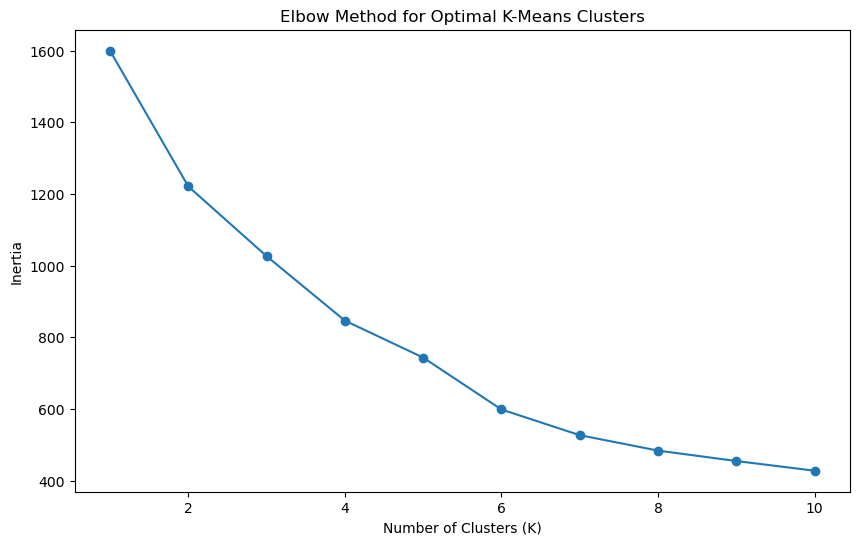

c:\Users\Raphael Frogoso\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


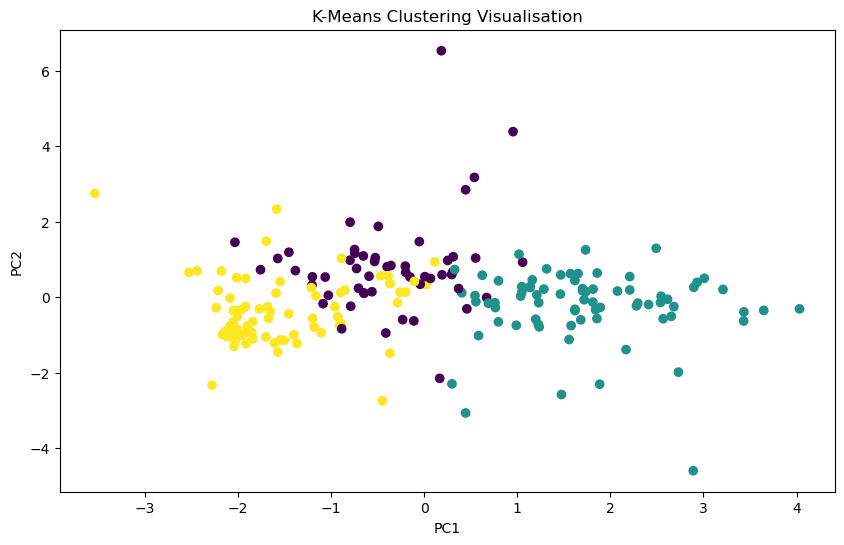

In [ ]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Select numerical columns only
final_numeric = sdg_combined_df.select_dtypes(include='number')

# Standardise the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(final_numeric)

# Elbow Method to find optimal K
inertia = []

K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(10, 6))

plt.plot(
    K_range,
    inertia,
    marker='o'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K-Means Clusters")

plt.grid(False)

plt.show()

# Apply K-Means using chosen K
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(scaled_data)

# Add cluster labels to dataset
sdg_combined_df['Cluster'] = clusters

# PCA for visualisation
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_data)

# Scatter plot of clusters
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    pca_components[:, 0],
    pca_components[:, 1],
    c=clusters
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clustering Visualisation")

plt.grid(False)

plt.show()